In [1]:
import sys
sys.path.append('/Users/albertsmith/Documents/GitHub.nosync/')
sys.path.append('/Users/albertsmith/Documents/GitHub/')

In [2]:
import SLEEPY as sl
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size']=14

Loading Defaults from file


<Axes: >

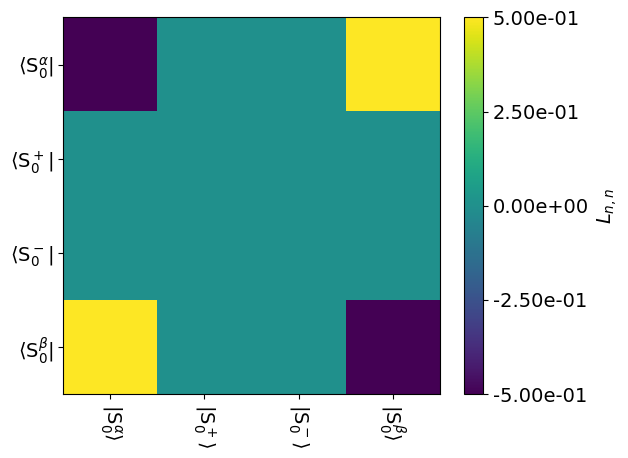

In [6]:
ex=sl.ExpSys(600,Nucs='1H')
L=ex.Liouvillian().add_relax('T1',i=0,T1=1)
L.plot('Lrelax',mode='re')

<Axes: >

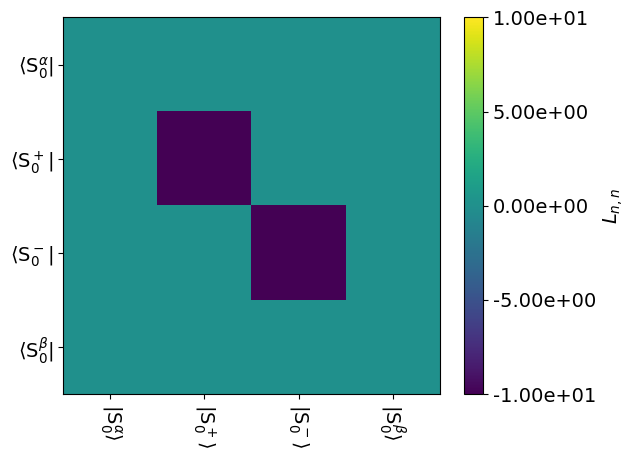

In [8]:
ex=sl.ExpSys(600,Nucs='1H')
L=ex.Liouvillian().add_relax('T2',i=0,T2=.1)
L.plot('Lrelax',mode='re')

In [9]:
# Calculate size of the one-bond dipole coupling for H–N
delta=sl.Tools.dipole_coupling(.102,'15N','1H')  #Distance, nuc1, nuc2

# Define field, nuclei, spinning speed, powder average

ex0=sl.ExpSys(500,Nucs=['15N','1H'],vr=60000)

ex0.set_inter('dipole',i0=0,i1=1,delta=22000)
ex0.set_inter('CSA',i=0,delta=113)

ex1=ex0.copy()
ex1.set_inter('dipole',i0=0,i1=1,delta=delta,euler_d=[0,20,0])  
ex1.set_inter('CSA',i=0,delta=113,euler_d=[0,20,0])


# This powder average is too big, and we'll change it later
# We want it here for displaying the couplings

# Define interactions (dipole, CSA, chemical shift)
ex0.set_inter('dipole',i0=0,i1=1,delta=delta)
ex0.set_inter('CSA',i=0,delta=113,euler_d=[0,23,0])
ex0.set_inter('CS',i=0,ppm=-5)

# Copy system
ex1=ex0.copy()
# Redefine dipole, CSA, with same magnitude, but different orientation (20 degree hop)
ex1.set_inter('dipole',i0=0,i1=1,delta=delta,euler_d=[0,20,45])  
ex1.set_inter('CSA',i=0,delta=113,euler_d=[[0,23,0],[0,20,45]])
# Redefine chemical shift, with 10 ppm change
_=ex1.set_inter('CS',i=0,ppm=5)


L=sl.Liouvillian(ex0,ex1,kex=sl.Tools.twoSite_kex(tc=1e-4))

L.add_relax('SpinDiffusion',i=1,k=20)

seq=L.Sequence()
seq.add_channel('15N',v1=15000)

Sequence for the following Liouvillian:
	Liouvillian under the following conditions:
		2-spin system (15N,1H)
		B0 = 11.743 T (500.000 MHz 1H frequency)
		rotor angle = 54.736 degrees
		rotor frequency = 60.0 kHz
		Temperature = 298 K
		Powder Average: JCP59 with 99 angles
	
	The individual Hamiltonians have the following interactions
		Hamiltonian #0
			dipole between spins 0,1 with arguments:
				(delta=-22954.84)
			CSA on spin 0 with arguments: (delta=113.00,euler=[0.00,23.00,0.00])
			CS on spin 0 with arguments: (ppm=-5.00)
		
		Hamiltonian #1
			dipole between spins 0,1 with arguments:
				(delta=-22954.84,euler=[0.00,20.00,45.00])
			CSA on spin 0 with arguments: (delta=113.00,euler=[0.00,23.00,0.00],[0.00,20.00,45.00])
			CS on spin 0 with arguments: (ppm=5.00)
		
		
	Hamiltonians are coupled by exchange matrix:
		array([[-5000.,  5000.],
		       [ 5000., -5000.]])
	
	Explicit relaxation
		SpinDiffusion with arguments: i = 1, k = 20

Default sequence length is 16.67 microseco

In [10]:
rho=sl.Rho(rho0='15Nx',detect='15Nx')

rho.DetProp(seq,n=12000)

_=rho.plot()

array([[-20.+0.j,   0.+0.j,   0.+0.j, ...,   0.+0.j,   0.+0.j,   0.+0.j],
       [  0.+0.j, -40.+0.j,   0.+0.j, ...,   0.+0.j,   0.+0.j,   0.+0.j],
       [  0.+0.j,   0.+0.j, -20.+0.j, ...,   0.+0.j,   0.+0.j,   0.+0.j],
       ...,
       [  0.+0.j,   0.+0.j,   0.+0.j, ..., -20.+0.j,   0.+0.j,   0.+0.j],
       [  0.+0.j,   0.+0.j,   0.+0.j, ...,   0.+0.j, -40.+0.j,   0.+0.j],
       [  0.+0.j,   0.+0.j,   0.+0.j, ...,   0.+0.j,   0.+0.j, -20.+0.j]])